## 🧩 Customer Segmentation - Unsupervised ML Project 

📌 Project Overview

This project applies K-Means clustering to segment customers based on their age, annual income, and spending score.
The goal is to identify distinct customer groups and provide business insights and marketing strategies for each segment.

💡 The dataset is from Kaggle and contains 1000 customers' information including:

* Age – customer's age
* Annual Income (k$) – yearly income in thousands
* Spending Score (1–100) – how much the customer spends

Each row represents one customer.

### 📁 Importing libraries & inspecting the dataset

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import  silhouette_score
from sklearn import datasets
from scipy.cluster.hierarchy import dendrogram, linkage 
from scipy.cluster.hierarchy import dendrogram
from yellowbrick.cluster import SilhouetteVisualizer
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("/Users/vasiagalanopoulou/Desktop/customer-segmentation-project/dataset/store_customers.csv")

In [4]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
...,...,...,...,...,...
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


### 🧹 Data Cleaning

In [6]:
df = df.dropna()

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,982.000000,982.000000,982.000000,982.000000
mean,1500.304481,38.958248,57.326782,42.603870
std,288.698083,13.417748,28.658961,20.121469
min,1000.000000,18.000000,15.000000,1.000000
25%,1251.250000,30.000000,35.125000,31.000000
50%,1499.500000,36.000000,49.150000,47.000000
75%,1750.750000,44.000000,79.475000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


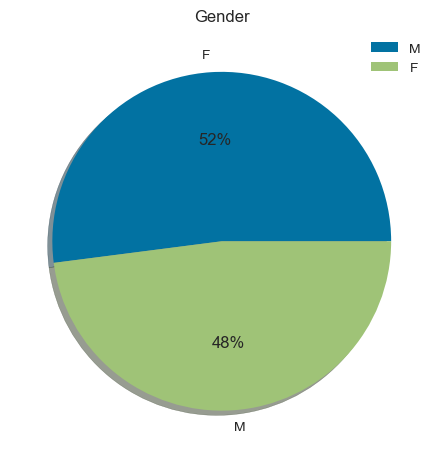

In [8]:
df['Gender'].value_counts().plot(kind='pie', autopct="%0.0f%%", shadow=True)

plt.title('Gender')
plt.ylabel('')
plt.legend(df['Gender'].unique(), loc='upper right')
plt.show()

In [9]:
df["Gender"] = df["Gender"].map({'M':1, 'F':0})
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,1,39.0,59.9,58.0
1,1001,1,34.0,48.4,37.0
2,1002,0,40.0,70.5,26.0
3,1003,0,47.0,81.1,30.0
4,1004,0,33.0,42.1,58.0
...,...,...,...,...,...
995,1995,1,80.0,133.3,1.0
996,1996,1,44.0,82.6,40.0
997,1997,0,46.0,67.7,26.0
998,1998,0,28.0,45.7,59.0


In [10]:
df = df.drop(columns='CustomerID')
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,39.0,59.9,58.0
1,1,34.0,48.4,37.0
2,0,40.0,70.5,26.0
3,0,47.0,81.1,30.0
4,0,33.0,42.1,58.0
...,...,...,...,...
995,1,80.0,133.3,1.0
996,1,44.0,82.6,40.0
997,0,46.0,67.7,26.0
998,0,28.0,45.7,59.0


In [11]:
df = df.rename(columns={
    "Annual Income (k$)": "AnnualIncome",
    "Spending Score (1-100)": "SpendingScore"
})

### 🔎 EDA

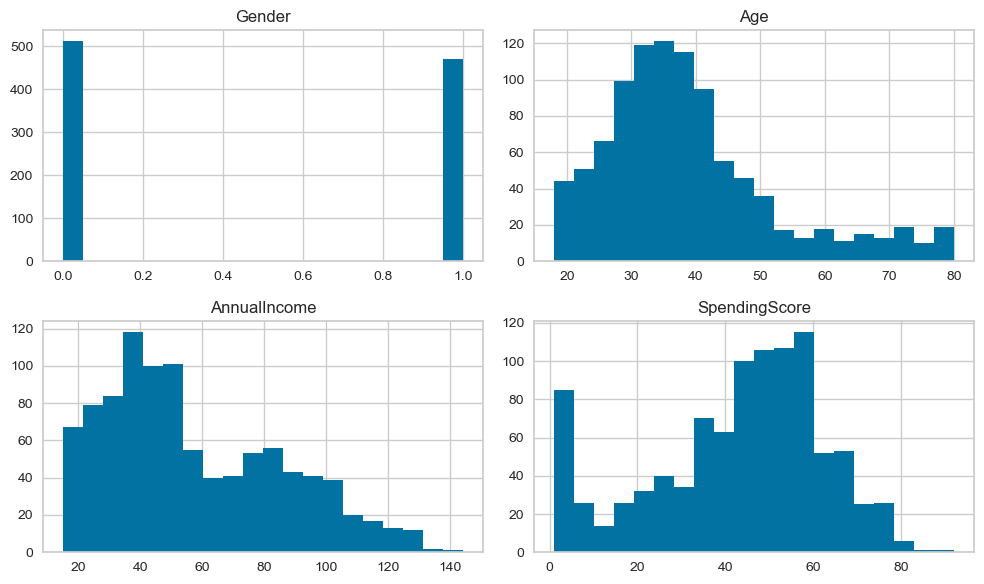

In [12]:
df.hist(figsize=(10,6), bins=20)
plt.tight_layout()
plt.show()

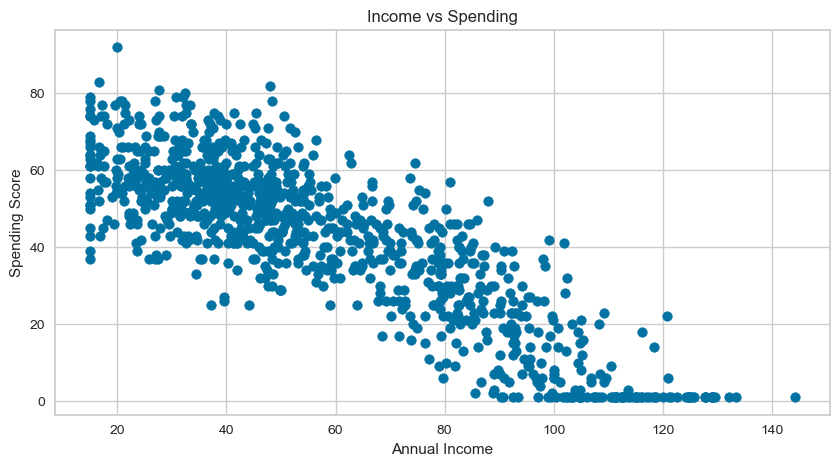

In [13]:
plt.figure(figsize=(10,5))
plt.scatter(df["AnnualIncome"],df["SpendingScore"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending")
plt.show()

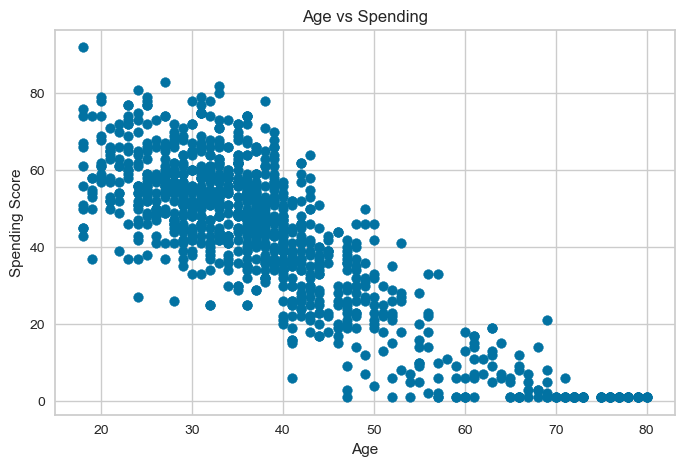

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(df["Age"],df["SpendingScore"])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending")
plt.show()

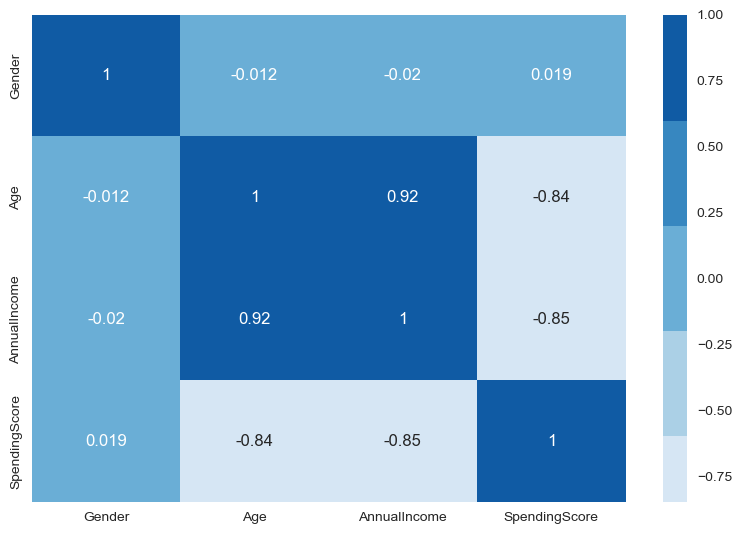

In [15]:
# Correlation heatmap

colors = sns.color_palette("Blues", 5)
correlation_matrix = df[['Gender', 'Age', 'AnnualIncome', 'SpendingScore']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap=colors, center=0)
plt.tight_layout()
plt.show()

<Axes: >

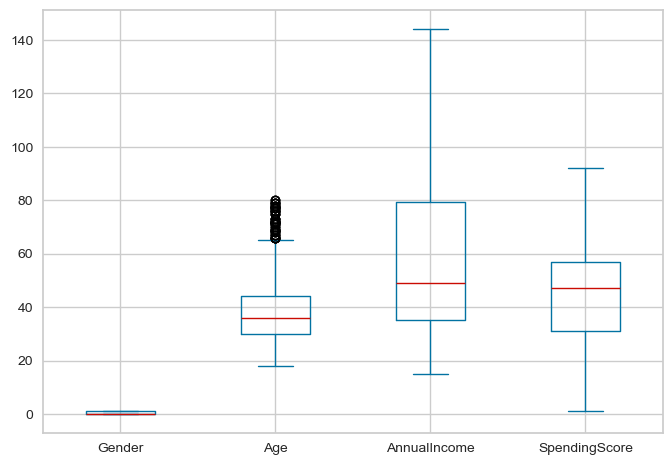

In [16]:
df.plot(kind='box')

### 🧠 K-means Clustering

In [17]:
# Scaling 

scaler = StandardScaler()
features_to_scale = ['Age', 'AnnualIncome', 'SpendingScore']
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

In [18]:
X = df_scaled[['AnnualIncome', 'SpendingScore']].values

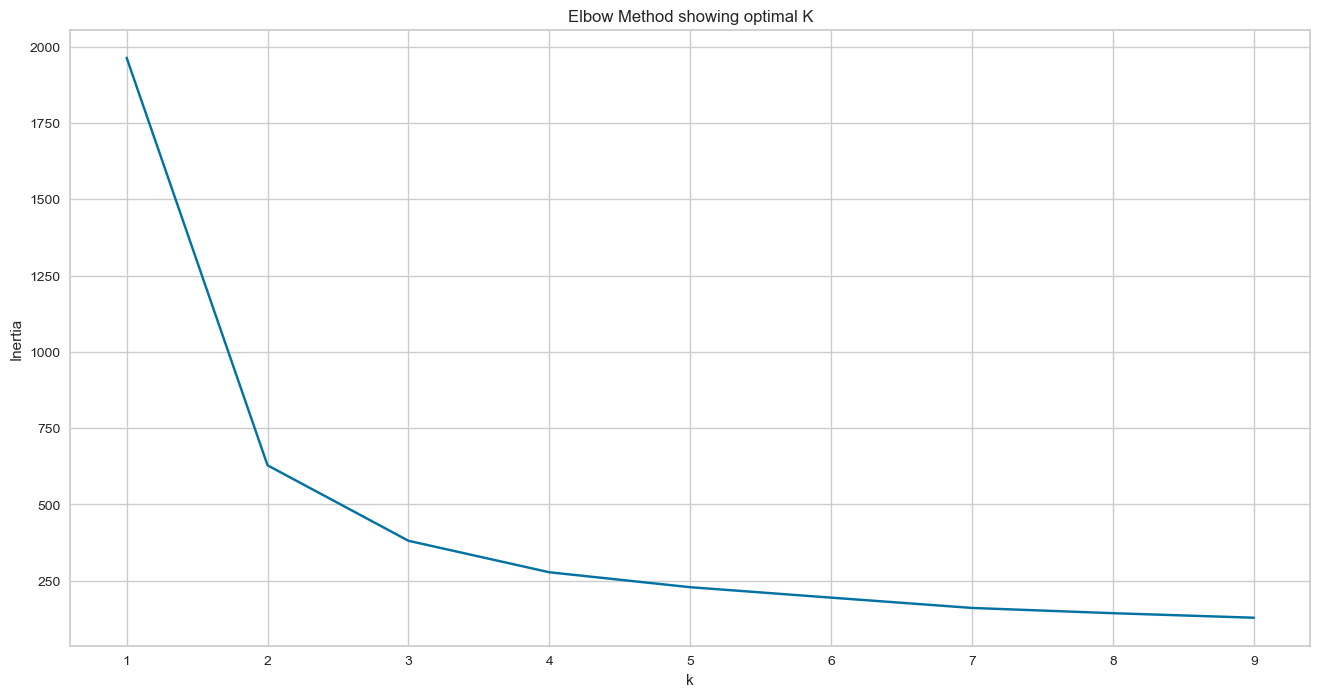

In [19]:
# Elbow Method

inertia = []
K = range(1,10)
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(X)
    inertia.append(kmeanModel.inertia_)

plt.figure(figsize=(16,8))
plt.plot(K,inertia,'bx-')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method showing optimal K")
plt.show()

For n_clusters = 2 The average silhouette_score is : 0.5835726782241136
For n_clusters = 3 The average silhouette_score is : 0.474495190991453
For n_clusters = 4 The average silhouette_score is : 0.3960437822584954
For n_clusters = 5 The average silhouette_score is : 0.3537496453205684
For n_clusters = 6 The average silhouette_score is : 0.37070825274741886


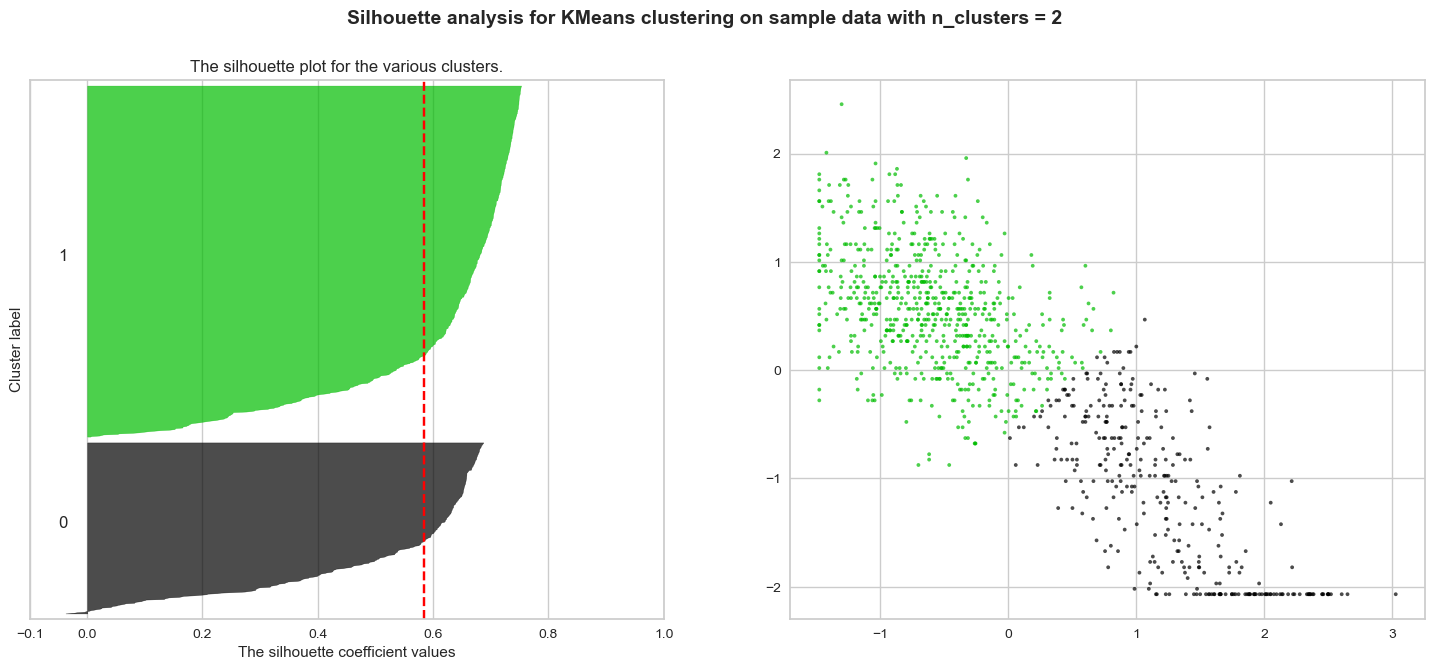

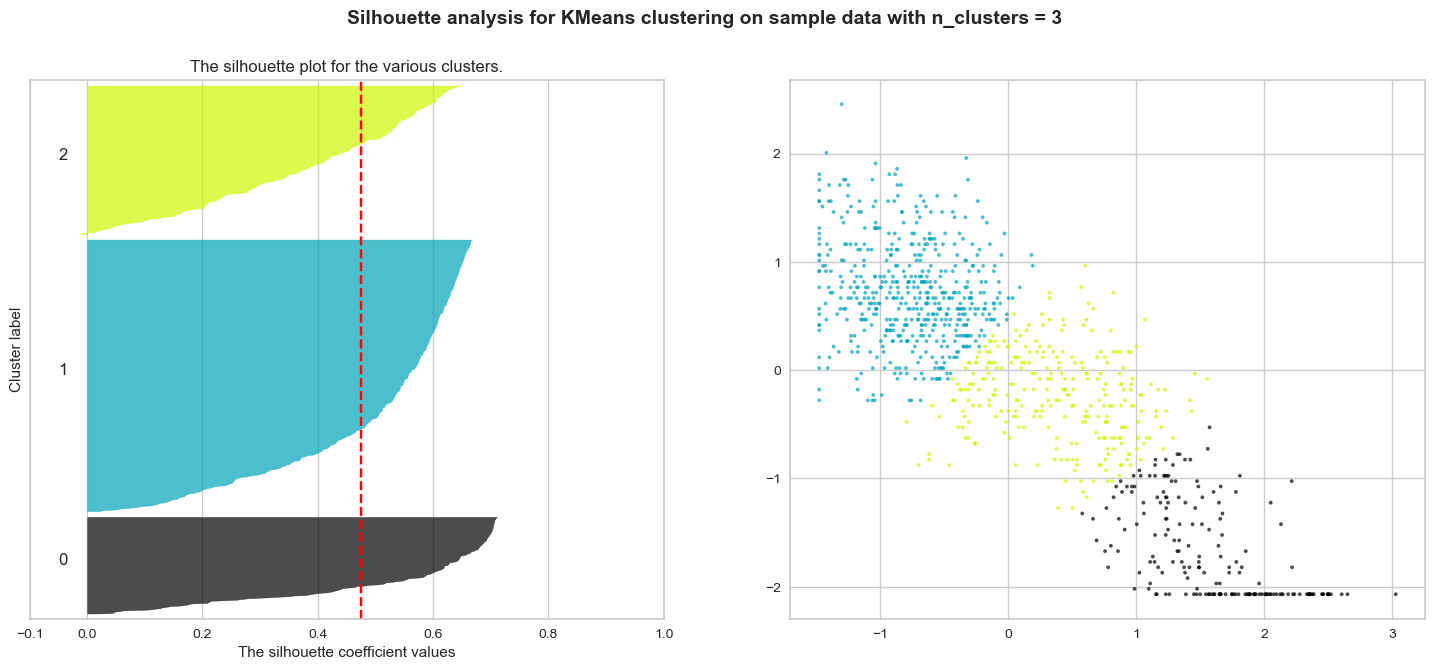

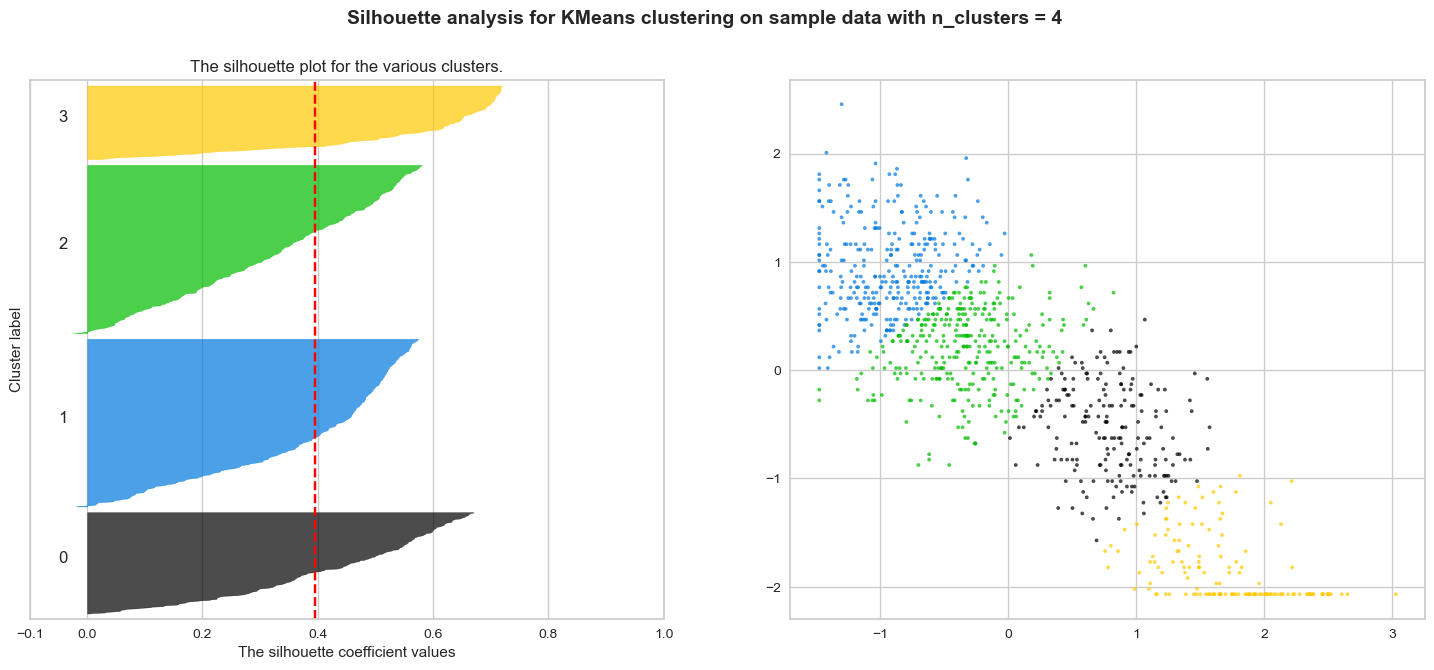

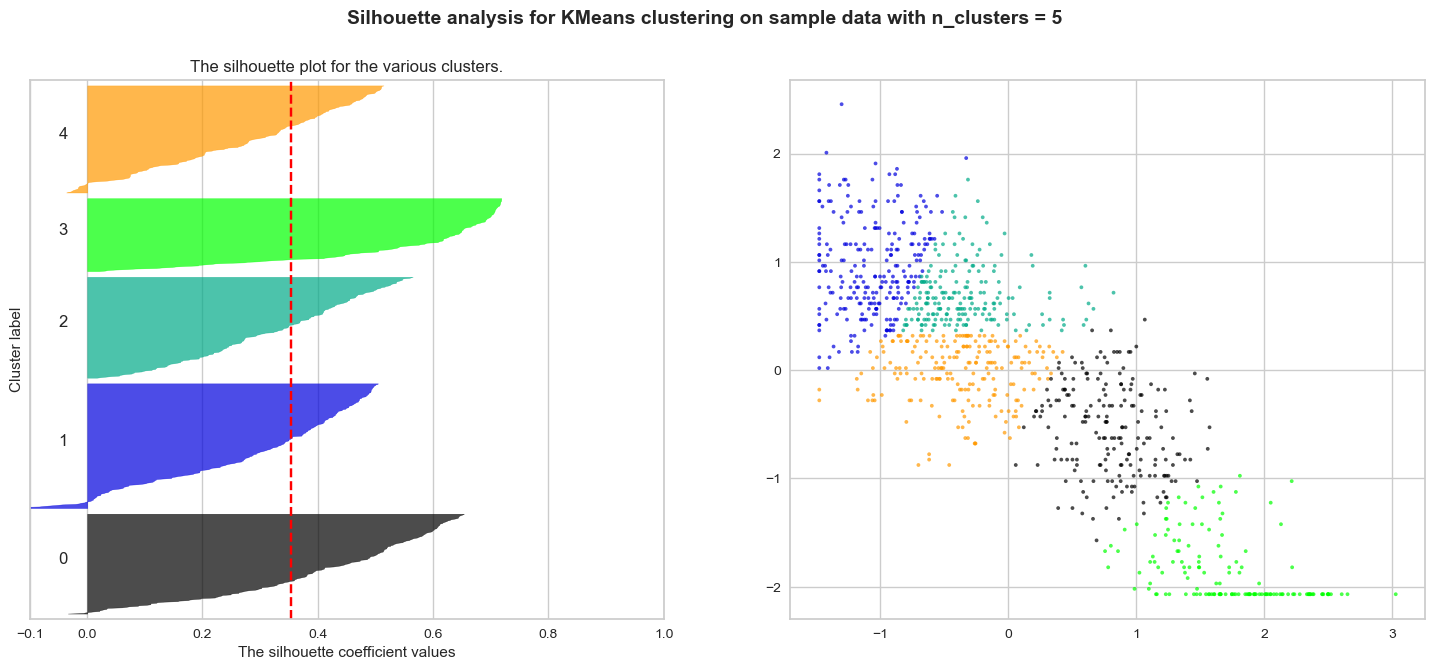

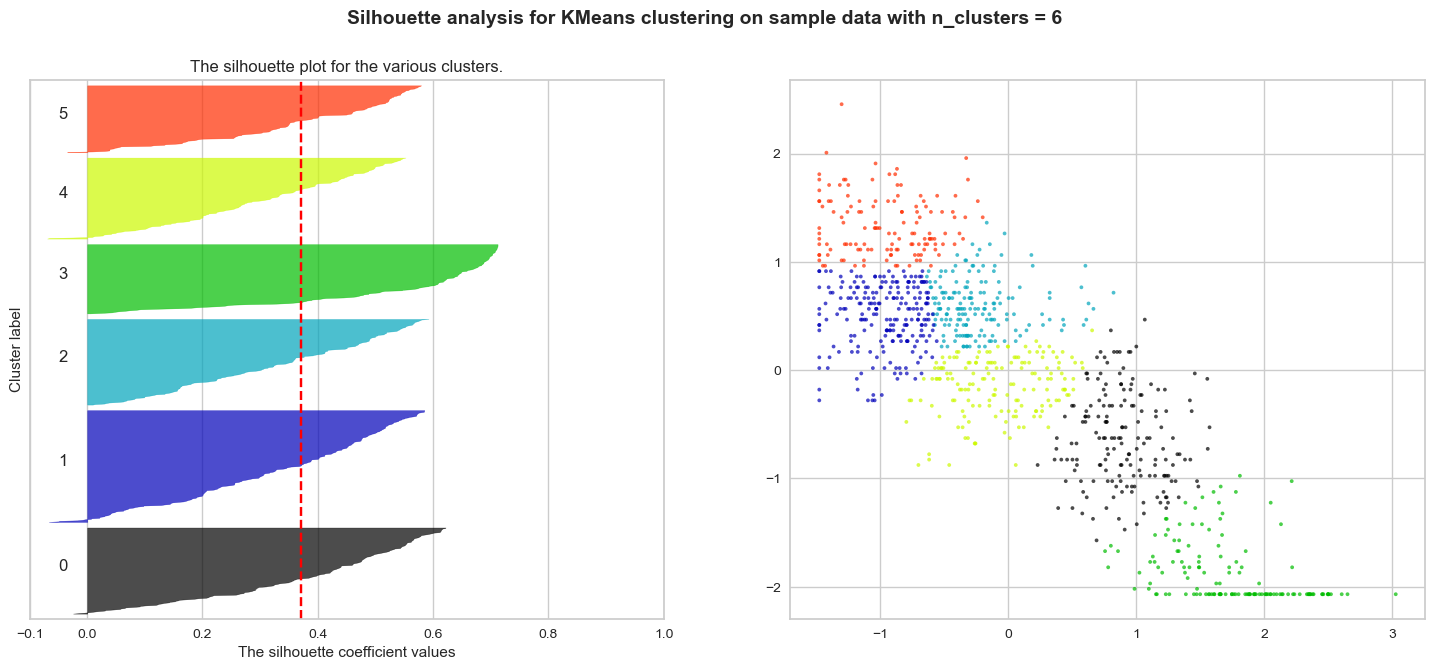

In [24]:
# Silhouette Score

import matplotlib.cm as cm
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score


range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

In [25]:
# Based on the elbow method & the Silhouette Score, let's use k=5

optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Add cluster labels to the original dataframe
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = cluster_labels

In [26]:
df_with_clusters

,Gender,Age,AnnualIncome,SpendingScore,Cluster
0,1,39.0,59.9,58.0,1
1,1,34.0,48.4,37.0,1
2,0,40.0,70.5,26.0,2
3,0,47.0,81.1,30.0,2
4,0,33.0,42.1,58.0,3
...,...,...,...,...,...
995,1,80.0,133.3,1.0,4
996,1,44.0,82.6,40.0,2
997,0,46.0,67.7,26.0,2
998,0,28.0,45.7,59.0,3


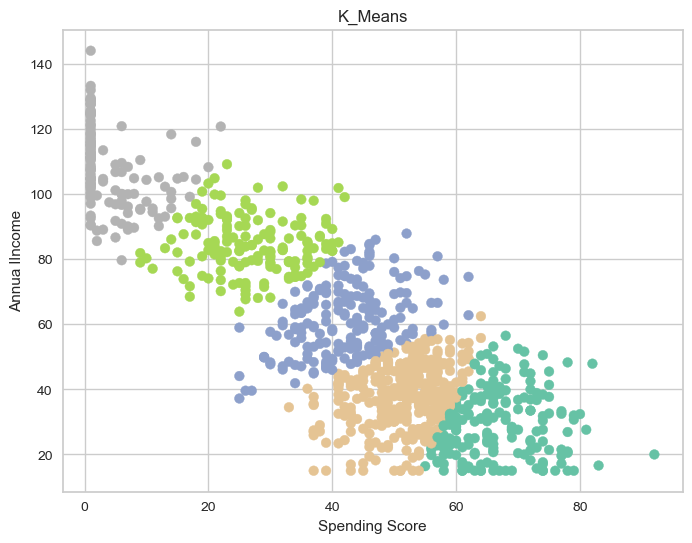

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(df_with_clusters['SpendingScore'], df_with_clusters['AnnualIncome'], c=df_with_clusters["Cluster"], cmap=plt.cm.Set2,)
plt.title("K_Means")
plt.xlabel("Spending Score")
plt.ylabel("Annua lIncome")
plt.show()

In [29]:
# Check average values per cluster

kmeans_group_df = df_with_clusters
kmeans_group_df = kmeans_group_df.groupby('Cluster').median()
kmeans_group_df

,Gender,Age,AnnualIncome,SpendingScore
Cluster,,,,
0,0.0,28.0,29.30,66.0
1,1.0,39.0,60.15,42.5
2,0.0,46.0,83.60,26.0
3,0.0,32.0,38.90,52.0
4,0.0,67.0,106.40,1.0


In [30]:
kmeans_group_df = kmeans_group_df.reset_index()
kmeans_group_df.head()

,Cluster,Gender,Age,AnnualIncome,SpendingScore
0,0,0.0,28.0,29.30,66.0
1,1,1.0,39.0,60.15,42.5
2,2,0.0,46.0,83.60,26.0
3,3,0.0,32.0,38.90,52.0
4,4,0.0,67.0,106.40,1.0


👥 We identify the 5 clusters.

0: **“Young impulsive spenders.”**
* Mean  Age: 28
* Mean Annual  Income: 29k
* Mean Spending Score: 66

1: **“Average middle-class customers.”**
* Mean  Age: 28
* Mean Annual  Income: 29k
* Mean Spending Score: 66
  
2: **“High-income conservative spenders.”**
* Mean  Age: 28
* Mean Annual  Income: 29k
* Mean Spending Score: 66
  
3: **“Young active shoppers.”**
* Mean  Age: 28
* Mean Annual  Income: 29k
* Mean Spending Score: 66

4: **“Very Wealthy but inactive customers.”**
* Mean  Age: 28
* Mean Annual  Income: 29k
* Mean Spending Score: 66

In [31]:
kmeans_group_df["Cluster"] = kmeans_group_df["Cluster"].map({0:'Young impulsive spenders', 1:'Average middle-class customers',2:'High-income conservative spenders',3:'Young active shoppers',4:'Very Wealthy but inactive customers'})

In [32]:
kmeans_group_df

,Cluster,Gender,Age,AnnualIncome,SpendingScore
0,Young impulsive spenders,0.0,28.0,29.30,66.0
1,Average middle-class customers,1.0,39.0,60.15,42.5
2,High-income conservative spenders,0.0,46.0,83.60,26.0
3,Young active shoppers,0.0,32.0,38.90,52.0
4,Very Wealthy but inactive customers,0.0,67.0,106.40,1.0


### 📊 Visualizations 

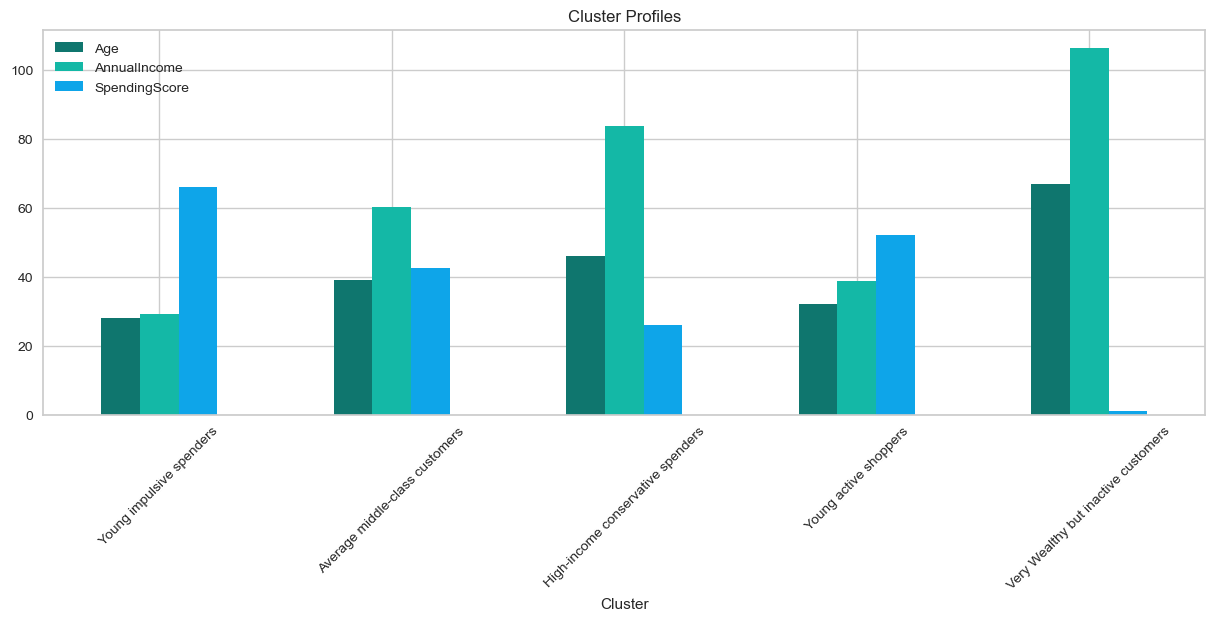

In [33]:
kmeans_group_df.set_index("Cluster")[["Age","AnnualIncome","SpendingScore"]].plot(
        kind="bar",rot=45,
        figsize=(15,5),color = ["#0f766e", "#14b8a6", "#0ea5e9"]
)

plt.title("Cluster Profiles")
plt.show()

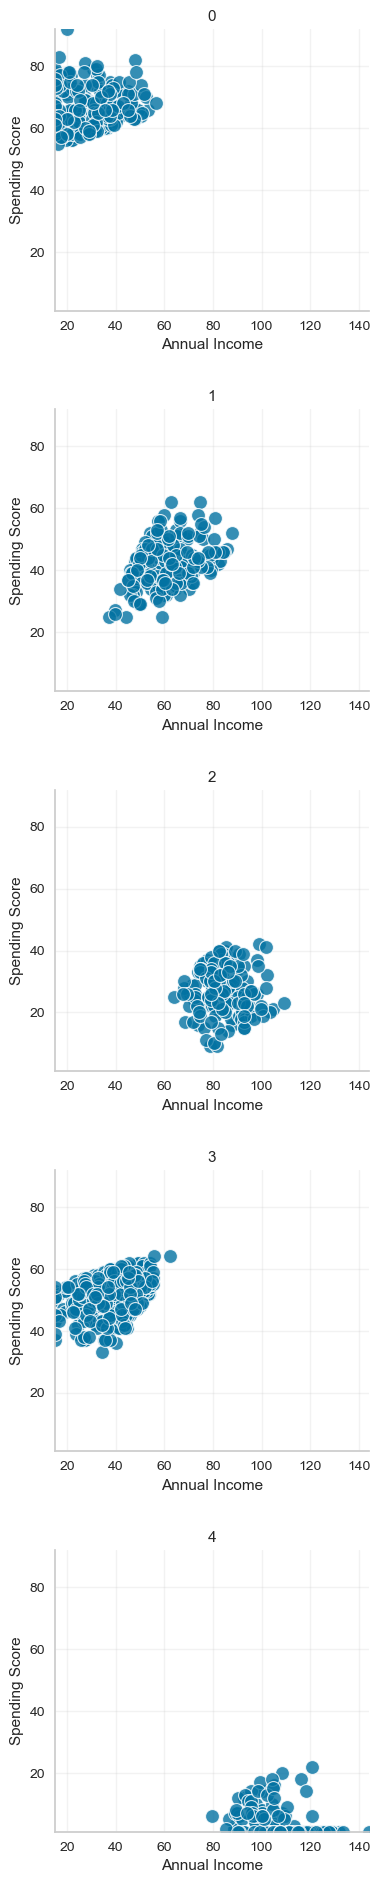

In [41]:
cluster_map = {
    0: "Young impulsive spenders",
    1: "Average middle-class customers",
    2: "High-income conservative spenders",
    3: "Young active shoppers",
    4: "Very Wealthy but inactive customers"
}

x_min, x_max = df_with_clusters["AnnualIncome"].min(), df_with_clusters["AnnualIncome"].max()
y_min, y_max = df_with_clusters["SpendingScore"].min(), df_with_clusters["SpendingScore"].max()

g = sns.FacetGrid(
    df_with_clusters,
    col="Cluster",
    col_wrap=1,
    height=4,
    sharex=False,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="AnnualIncome",
    y="SpendingScore",
    s=100,
    alpha=0.8
)

for ax in g.axes.flat:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # force labels on every subplot
    ax.set_xlabel("Annual Income")
    ax.set_ylabel("Spending Score")
    ax.tick_params(axis="x", labelbottom=True)
    ax.tick_params(axis="y", labelleft=True)

    ax.spines["bottom"].set_visible(True)
    ax.spines["left"].set_visible(True)
    ax.grid(alpha=0.25)

g.set_titles("{col_name}")
g.fig.subplots_adjust(hspace=0.35, wspace=0.15, bottom=0.08)  
plt.show()


### 📈 Business Insights - Marketing Strategy

0: **“Young impulsive spenders.”**
* Flash sales
* Social media ads
* Limited offers
* Influencer marketing

1: **“Average middle-class customers.”**
* loyalty programs
* personalized promotions
* seasonal offers
  
2: **“High-income conservative spenders.”**
* premium experiences
* exclusive offers
* luxury branding
  
3: **“Young active shoppers.”**
* membership programs
* bundles
* frequent buyer rewards

4: **“Very Wealthy but inactive customers.”**
* luxury experiences
* personalized services
* exclusive VIP events